In [2]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
import math
import json
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)
from ultralytics import YOLO
from utils import *

In [3]:
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model = YOLO(os.path.join(model_path, "yolov8n.pt"))

In [4]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name =  'real_test'


0: 288x640 17 persons, 1 ball, 7.7ms
Speed: 7.6ms preprocess, 7.7ms inference, 0.9ms postprocess per image at shape (1, 3, 288, 640)


True


/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)

0: 320x640 10 persons, 1 ball, 7.7ms
Speed: 1.5ms preprocess, 7.7ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 640)
/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)

0: 288x640 11 persons, 7.3ms
Speed: 1.3ms preprocess, 7.3ms inference, 1.1ms postprocess per image at shape (1, 3, 288, 640)
/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The defau

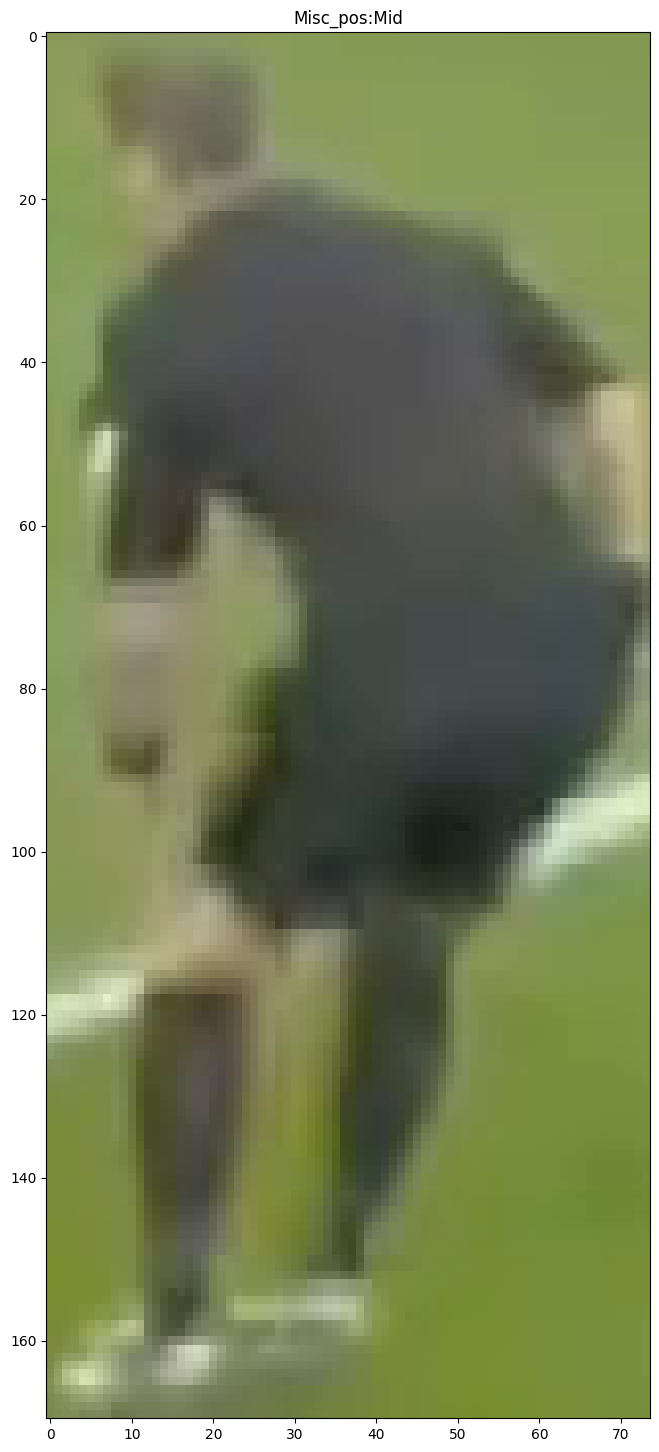

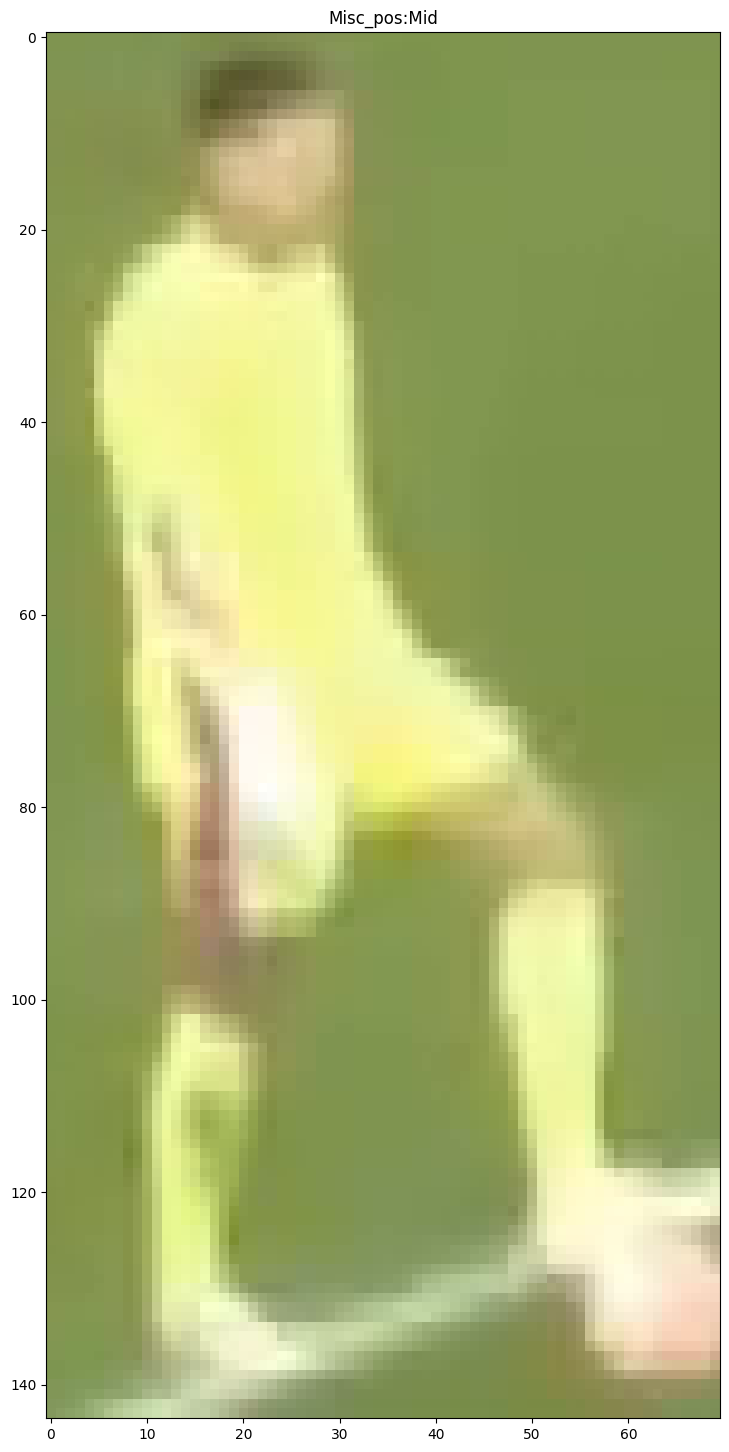

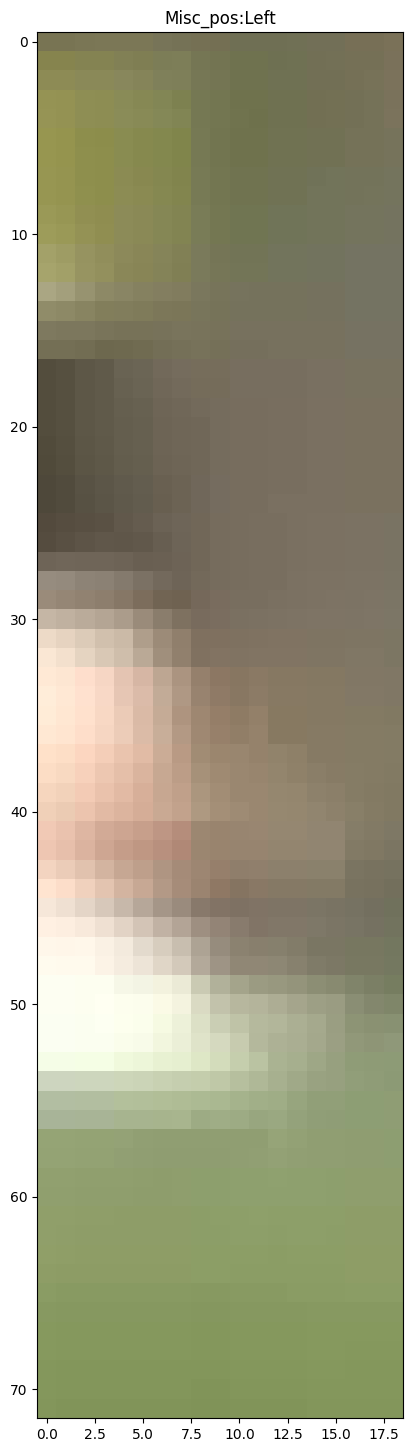

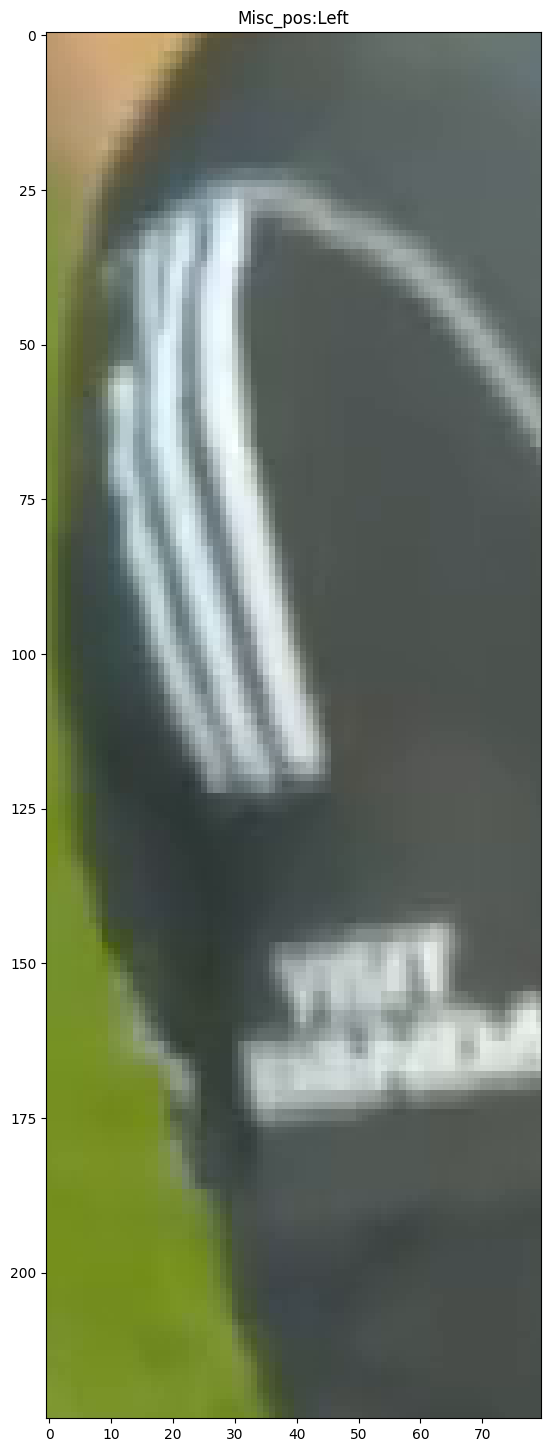

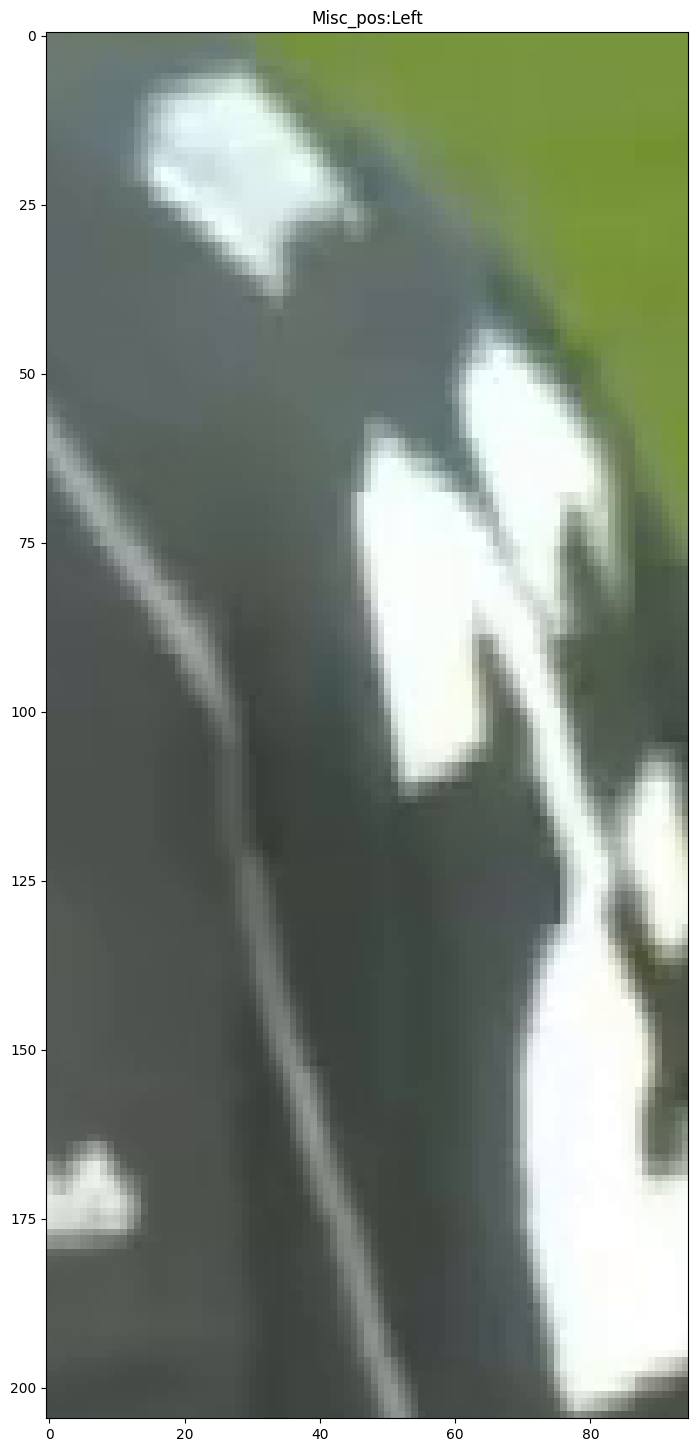

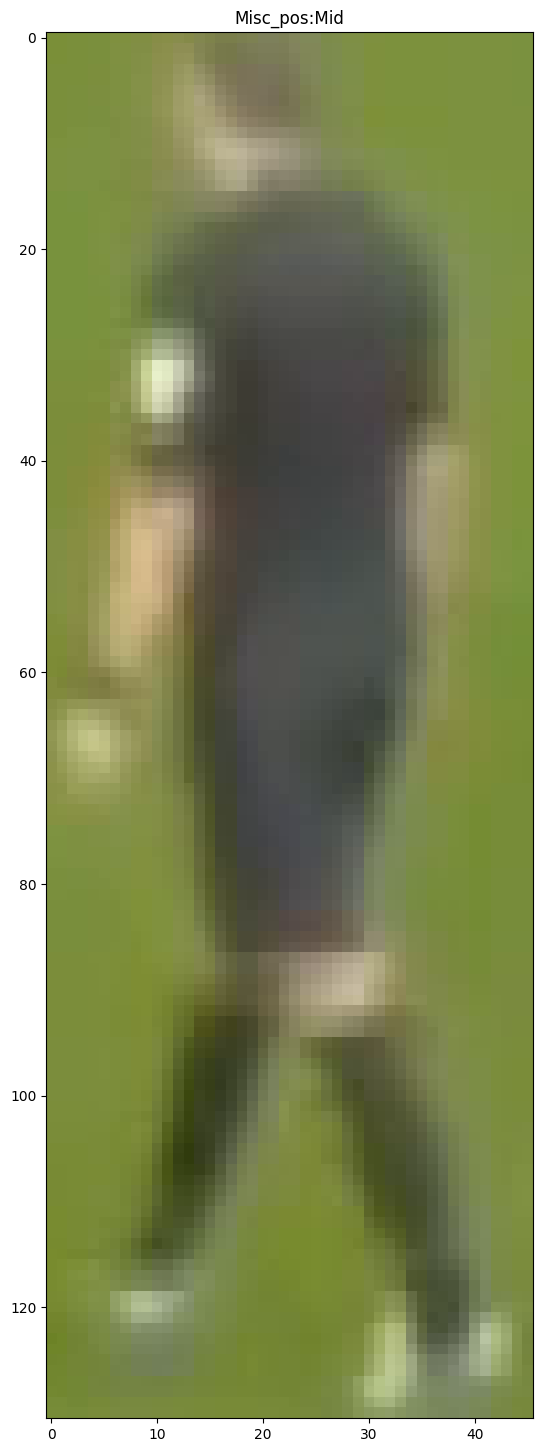

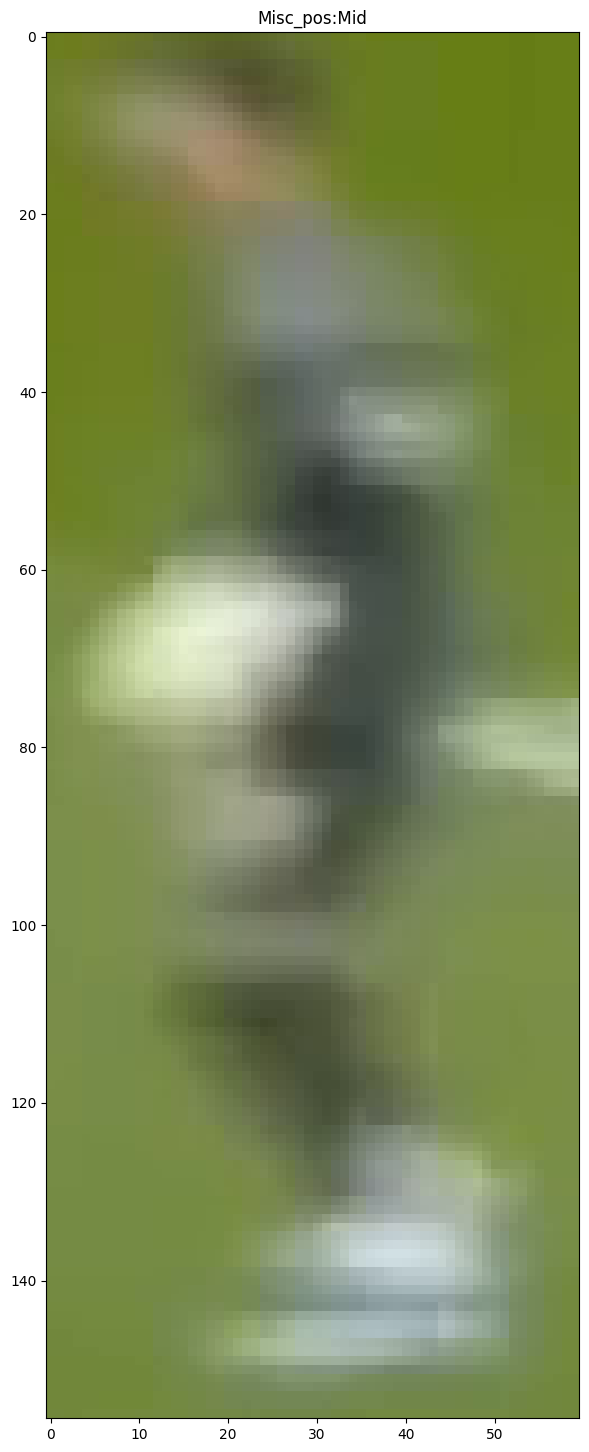

In [38]:
from sklearn.cluster import KMeans
from collections import Counter
from colormath.color_objects import sRGBColor, LabColor
from colormath.color_conversions import convert_color
from colormath.color_diff import delta_e_cie2000

images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
first_batch = os.listdir(images_path)[0:20]
image_batch = [os.path.join(images_path, x) for x in first_batch]        # Get several images to test

team_1_color_global = []
team_2_color_global = []
team_position_global = []

misc_color_global   = []
misc_position_global = []
misc_frequency_global = []
misc_img_global = []

frame_num = 0


for image_ad in image_batch:
    rgb_image = cv2.imread(image_ad, cv2.COLOR_BGR2RGB)

    ## pitch seg
    hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
    lower_green = np.array([35, 20, 50])
    upper_green = np.array([90, 255, 255])

    mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
    result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
    temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
    h, w, _ = result.shape
    _, green, _ = cv2.split(temp)

    #ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)

    contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

    contours = max(contours, key=cv2.contourArea)
    rect = np.int16(cv2.boundingRect(contours))
    min_x, min_y, w, h = rect
    max_x, max_y = [min_x + w, min_y + h]
    #cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
    cv2.rectangle(temp, (min_x, min_y), (max_x, max_y),color=(255, 0, 0), thickness=5)

    # Crop the image
    result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
    rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))
    #plt.figure()
    #plt.imshow(rgb_image[:,:,::-1])
    ## run the model

    results = model.predict(rgb_image)
    boxes = results[0].boxes
    # Compute hue of grass
    grass_average = rgb_image[:,:,::-1].mean(axis=0).mean(axis=0) 
    # Assignment 
    assignment=[]
    player_x_coord = []
    crop_img_list = []
    
    for box in boxes:
        if box.cls[0].item() == 0:   # if the person then continue to compute hue
            crop = box.xyxy
            (startX, startY, endX, endY) = np.concatenate(crop.cpu().detach().int().tolist())
            player_saved = rgb_image[startY:endY,startX:endX]
            player_x_coord.append(0.5*(startX + endX))
            crop_img_list.append(player_saved[:,:,::-1])
            # Z threshold% area of the box into account
            z = 0.4
            new_startY = round(startY + (1-np.sqrt(z))*(endY-startY)/2)
            new_endY = round((startY+endY)/2)#round(endY - (1-np.sqrt(z))*(endY-startY)/2)
            new_startX = round(startX + (1-np.sqrt(z))*(endX-startX)/2)
            new_endX = round(endX - (1-np.sqrt(z))*(endX-startX)/2)
            #--------------------
            cropped = rgb_image[new_startY:new_endY,new_startX:new_endX]
            test_crop = cropped[:,:,::-1].copy()
            #crop_img_list.append(test_crop)
            result = []
            for row_idx in range(cropped.shape[0]):
                for col_idx in range(cropped.shape[1]):        
                    current_color = test_crop[row_idx][col_idx]
                    if sum(abs(current_color - grass_average)) > 60:
                        result.append(current_color)
            final_color = np.mean(result,axis = 0)
            assignment.append(final_color)

    kmeans = KMeans(n_clusters=3)
    s=kmeans.fit(assignment)
    labels=kmeans.labels_
    teams = Counter(labels).most_common(3)
    team_1 = np.where(labels == teams[0][0])[0]
    team_2 = np.where(labels == teams[1][0])[0]
    misc   = np.where(labels == teams[2][0])[0]


    if frame_num == 0:
        team_1_color = np.mean([assignment[i] for i in team_1],axis =0)
        team_2_color = np.mean([assignment[i] for i in team_2],axis =0)
        # Metric CLE: Conversion -> Diff
        srgb_assignment = [sRGBColor(i[0], i[1], i[2]) for i in assignment]
        srgb_team_1_color = sRGBColor(team_1_color[0],team_1_color[1],team_1_color[2])
        srgb_team_2_color = sRGBColor(team_2_color[0],team_2_color[1],team_2_color[2])
        lab_assignment = [convert_color(x,LabColor) for x in srgb_assignment]
        lab_team_1_color = convert_color(srgb_team_1_color, LabColor)
        lab_team_2_color = convert_color(srgb_team_2_color, LabColor)
        team_1_color_global = lab_team_1_color 
        team_2_color_global = lab_team_2_color
        team_1_check = [delta_e_cie2000(lab_team_1_color, lab_assignment[i]) for i in team_1]
        team_2_check = [delta_e_cie2000(lab_team_2_color, lab_assignment[i]) for i in team_2]
        convert_misc_1_idx = [i for i in range(len(team_1_check)) if team_1_check[i] > 50] 
        convert_misc_2_idx = [i for i in range(len(team_2_check)) if team_2_check[i] > 50]

        if len(convert_misc_1_idx) > 0:
            for x in convert_misc_1_idx:
                labels[x] = teams[2][0]
        if len(convert_misc_2_idx) > 0:
            for y in convert_misc_2_idx:
                labels[y] = teams[2][0]
        
        labels = list(map(lambda x: x if x != teams[0][0] else 'Team 1', labels))
        labels = list(map(lambda x: x if x != teams[1][0] else 'Team 2', labels))
        labels = list(map(lambda x: x if x != teams[2][0] else 'Misc', labels))
        
    
    if frame_num > 0:
        
        team_1_color = np.mean([assignment[i] for i in team_1],axis =0)
        team_2_color = np.mean([assignment[i] for i in team_2],axis =0)                        

        # Repetition to find the misc: Write the correct red
        srgb_assignment = [sRGBColor(i[0], i[1], i[2]) for i in assignment]
        srgb_team_1_color = sRGBColor(team_1_color[0],team_1_color[1],team_1_color[2])
        srgb_team_2_color = sRGBColor(team_2_color[0],team_2_color[1],team_2_color[2])
        lab_assignment = [convert_color(x,LabColor) for x in srgb_assignment]
        lab_team_1_color = convert_color(srgb_team_1_color, LabColor)
        lab_team_2_color = convert_color(srgb_team_2_color, LabColor)
        team_1_check = [delta_e_cie2000(lab_team_1_color, lab_assignment[i]) for i in team_1]
        team_2_check = [delta_e_cie2000(lab_team_2_color, lab_assignment[i]) for i in team_2]
        convert_misc_1_idx = [i for i in range(len(team_1_check)) if team_1_check[i] > 50] 
        convert_misc_2_idx = [i for i in range(len(team_2_check)) if team_2_check[i] > 50]

        if len(convert_misc_1_idx) > 0:
            for x in convert_misc_1_idx:
                if delta_e_cie2000(lab_team_2_color,lab_assignment[x]) < 30:
                    labels[x] = teams[1][0]
                else:
                    labels[x] = teams[2][0]
        
        if len(convert_misc_2_idx) > 0:
            for y in convert_misc_2_idx:
                if delta_e_cie2000(lab_team_1_color,lab_assignment[y]) < 30:
                    labels[y] = teams[0][0]
                else:
                    labels[y] = teams[2][0]
                

        

        # Update the label so that team X is always color Y 
        global_1_vs_local_1 = delta_e_cie2000(team_1_color_global, lab_team_1_color)
        global_1_vs_local_2 = delta_e_cie2000(team_1_color_global, lab_team_2_color)
        if  global_1_vs_local_1 < global_1_vs_local_2:
            labels = list(map(lambda x: x if x != teams[0][0] else 'Team 1', labels))
            labels = list(map(lambda x: x if x != teams[1][0] else 'Team 2', labels))
        else: 
            labels = list(map(lambda x: x if x != teams[1][0] else 'Team 1', labels))
            labels = list(map(lambda x: x if x != teams[0][0] else 'Team 2', labels))
        labels = list(map(lambda x: x if x != teams[2][0] else 'Misc', labels)) 

    # Positional of the two teams
    new_team_1 = np.where(np.array(labels) == "Team 1")[0]
    new_team_2 = np.where(np.array(labels) == "Team 2")[0]
    new_misc   = np.where(np.array(labels) == "Misc")[0]    
    
    avg_x_team_1 = np.mean([player_x_coord[i] for i in new_team_1])
    #avg_y_team_1 = np.mean([player_y_coord[i] for i in new_team_1])
    avg_x_team_2 = np.mean([player_x_coord[i] for i in new_team_2])
    #avg_y_team_2 = np.mean([player_y_coord[i] for i in new_team_2]) 
    if avg_x_team_1 < avg_x_team_2:
        left_coord = avg_x_team_1
    else:
        left_coord = avg_x_team_2
    
    # Update the misc color: 
    current_misc_img   = [crop_img_list[i] for i in new_misc]
    current_misc_color = [assignment[i] for i in new_misc]
    current_misc_pos   = [player_x_coord[i] for i in new_misc]
    current_misc_srgb = [sRGBColor(i[0], i[1], i[2]) for i in current_misc_color]
    current_misc_lab = [convert_color(i,LabColor) for i in current_misc_srgb]
    global_misc_srgb = [sRGBColor(i[0], i[1], i[2]) for i in misc_color_global]
    global_misc_lab = [convert_color(i,LabColor) for i in global_misc_srgb]
    switch = [False]*len(current_misc_lab)

    for i in range(len(current_misc_color)):
        if current_misc_pos[i] <= left_coord:
            current_misc_pos[i] = "Left"
        else:
            current_misc_pos[i] = "Right"

    # Check availability of the misc clr:
    if len(misc_color_global) == 0:
        for j in range(len(current_misc_color)):
            team_1_diff = delta_e_cie2000(current_misc_lab[j],team_1_color_global)
            team_2_diff = delta_e_cie2000(current_misc_lab[j],team_2_color_global)
            # If the same shade of color then update the param of existing global, but if it is not then addd into the list
            if (team_1_diff < 30) or (team_2_diff < 30):
                switch[j] = True
            if switch[j] == False:
                misc_img_global.append(current_misc_img[j])
                misc_color_global.append(current_misc_color[j])
                misc_position_global.append(current_misc_pos[j])
                misc_frequency_global.append(1)
    else:
        #global vs local:
        for j in range(len(current_misc_lab)):
            team_1_diff = delta_e_cie2000(current_misc_lab[j],team_1_color_global)
            team_2_diff = delta_e_cie2000(current_misc_lab[j],team_2_color_global)
            # If the same shade of color then update the param of existing global, but if it is not then add into the list
            if (team_1_diff < 30) or (team_2_diff < 30):
                #plt.figure()
                #plt.title("Misc_still have team color")
                #plt.imshow(current_misc_img[j])
                switch[j] = True
            for i in range(len(global_misc_lab)):
                misc_diff = delta_e_cie2000(global_misc_lab[i], current_misc_lab[j])
                if misc_diff < 30:
                    if current_misc_pos[j] == misc_position_global[i]:
                        misc_frequency_global[i] += 1
                    else:
                        misc_frequency_global[i] += 1
                        misc_position_global[i] = "Mid"
                    switch[j] = True

        for j in range(len(current_misc_lab)):
            if switch[j] == False:
                if len(misc_color_global) <= 6:
                    misc_img_global.append(current_misc_img[j])
                    misc_color_global.append(current_misc_color[j])
                    misc_position_global.append(current_misc_pos[j])
                    misc_frequency_global.append(1)
                else:
                    if min(misc_frequency_global) == 1:
                        k = misc_frequency_global.index(min(misc_frequency_global))
                        misc_img_global[k] = current_misc_img[j]
                        misc_color_global[k] = current_misc_color[j]
                        misc_position_global[k] = current_misc_pos[j]
                        misc_frequency_global[k] = 1
    
    frame_num +=1

for r in range(len(misc_img_global)):
    plt.figure()
    plt.title("Misc_pos:" + misc_position_global[r])
    plt.imshow(misc_img_global[r])



In [11]:
#!pip install colormath

In [4]:
import numpy

def patch_asscalar(a):
    return a.item()

setattr(numpy, "asscalar", patch_asscalar)

In [9]:
def area_reduction(startX, endX, startY, endY, threshold = 0.4):
    
    new_startY = round(startY + (1-np.sqrt(z))*(endY-startY)/2)
    new_endY = round((startY+endY)/2)#round(endY - (1-np.sqrt(z))*(endY-startY)/2)
    new_startX = round(startX + (1-np.sqrt(z))*(endX-startX)/2)
    new_endX = round(endX - (1-np.sqrt(z))*(endX-startX)/2)

    return new_startX, new_endX, new_startY, new_endY

In [ ]:
(startX, startY, endX, endY) = np.concatenate(crop.cpu().detach().int().tolist())
player_saved = rgb_image[startY:endY,startX:endX]
player_x_coord.append(0.5*(startX + endX))
crop_img_list.append(player_saved[:,:,::-1])
# Z threshold% area of the box into account
z = 0.4
new_startY = round(startY + (1-np.sqrt(z))*(endY-startY)/2)
new_endY = round((startY+endY)/2)#round(endY - (1-np.sqrt(z))*(endY-startY)/2)
new_startX = round(startX + (1-np.sqrt(z))*(endX-startX)/2)
new_endX = round(endX - (1-np.sqrt(z))*(endX-startX)/2)
#--------------------
cropped = rgb_image[new_startY:new_endY,new_startX:new_endX]

In [40]:
def box_to_features(rgb_image,boxes):
    assignment=[]
    player_x_coord = []
    crop_img_list = []

    #Compute the hue of grass:
    grass_average = rgb_image[:,:,::-1].mean(axis=0).mean(axis=0)

    for box in boxes:
        # Class is person then compute hue
        if box.cls[0].item() == 0:   
            crop = box.xyxy
            (x_1, y_1, x_2, y_2) = np.concatenate(crop.cpu().detach().int().tolist())
            player_saved = rgb_image[y_1:y_2,x_1:x_2]
            crop_img_list.append(player_saved[:,:,::-1])       # feature 1: player image for testing
            player_x_coord.append(0.5*(x_1 + x_2))         # feature 2: relative x coordinate of the player

            (new_x_1,new_x_2,new_y_1,new_y_2) = area_reduction(x_1,x_2,y_1,y_2) # update coodinates to capture only shirts
            cropped = rgb_image[new_y_1:new_y_2,new_x_1:new_x_2]
            test_crop = cropped[:,:,::-1].copy()

            # Select pixels for analysis:
            result = []
            for row_idx in range(cropped.shape[0]):
                for col_idx in range(cropped.shape[1]):        
                    current_color = test_crop[row_idx][col_idx]
                    if sum(abs(current_color - grass_average)) > 60:
                        result.append(current_color)
            final_color = np.mean(result,axis = 0)
            assignment.append(final_color)                     # feature 3: Color shirt of the player

    return assignment,player_x_coord,crop_img_list

In [11]:
def pitch_segmentation(rgb_image):
    ## pitch seg
    hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
    lower_green = np.array([35, 20, 50])
    upper_green = np.array([90, 255, 255])

    mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
    result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
    temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
    h, w, _ = result.shape
    _, green, _ = cv2.split(temp)

    #ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)

    contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

    contours = max(contours, key=cv2.contourArea)
    rect = np.int16(cv2.boundingRect(contours))
    min_x, min_y, w, h = rect
    max_x, max_y = [min_x + w, min_y + h]
    #cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
    cv2.rectangle(temp, (min_x, min_y), (max_x, max_y),color=(255, 0, 0), thickness=5)

    # Crop the image
    result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
    rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))

    return rgb_image

In [12]:
def rgb_to_lab(assignment):

    srgb = sRGBColor(assignment[0],assignment[1],assignment[2])
    lab = convert_color(srgb, LabColor)

    return lab

In [22]:
def misc_in_teams(labels,lab_assignment,lab_team_1_color,lab_team_2_color,teams,team_1,team_2,threshold = 50):

    result = labels
    team_1_check = [delta_e_cie2000(lab_team_1_color, lab_assignment[i]) for i in team_1]
    team_2_check = [delta_e_cie2000(lab_team_2_color, lab_assignment[i]) for i in team_2]
    convert_misc_1_idx = [i for i in range(len(team_1_check)) if team_1_check[i] > threshold] 
    convert_misc_2_idx = [i for i in range(len(team_2_check)) if team_2_check[i] > threshold]

    if len(convert_misc_1_idx) > 0:
            for x in convert_misc_1_idx:
                if delta_e_cie2000(lab_team_2_color,lab_assignment[x]) < 30:
                    result[x] = teams[1][0]
                else:
                    result[x] = teams[2][0]
            
    if len(convert_misc_2_idx) > 0:
            for y in convert_misc_2_idx:
                if delta_e_cie2000(lab_team_1_color,lab_assignment[y]) < 30:
                    result[y] = teams[0][0]
                else:
                    result[y] = teams[2][0]
    
    return result

In [16]:
def position_text(player_x_coord,new_team_1,new_team_2,new_misc):
    misc_pos = [player_x_coord[i] for i in new_misc]
    avg_x_team_1 = np.mean([player_x_coord[i] for i in new_team_1])
    avg_x_team_2 = np.mean([player_x_coord[i] for i in new_team_2])
    # Identify left vs right position
    if avg_x_team_1 < avg_x_team_2:
        left_coord = avg_x_team_1
    else:
        left_coord = avg_x_team_2
        
    for i in range(len(current_misc_color)):
        if misc_pos[i] <= left_coord:
            misc_pos[i] = "Left"
        else:
            misc_pos[i] = "Right"
    return misc_pos


0: 288x640 17 persons, 1 ball, 7.4ms
Speed: 1.3ms preprocess, 7.4ms inference, 0.8ms postprocess per image at shape (1, 3, 288, 640)
/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)

0: 320x640 10 persons, 1 ball, 7.3ms
Speed: 1.4ms preprocess, 7.3ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 640)
/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)

0: 288x640 11 persons, 7.4ms
Speed: 1.5ms preprocess, 7.4ms inference, 1.1ms postprocess per image at shape (1, 3, 288, 6

[13, 5, 1, 2, 2]


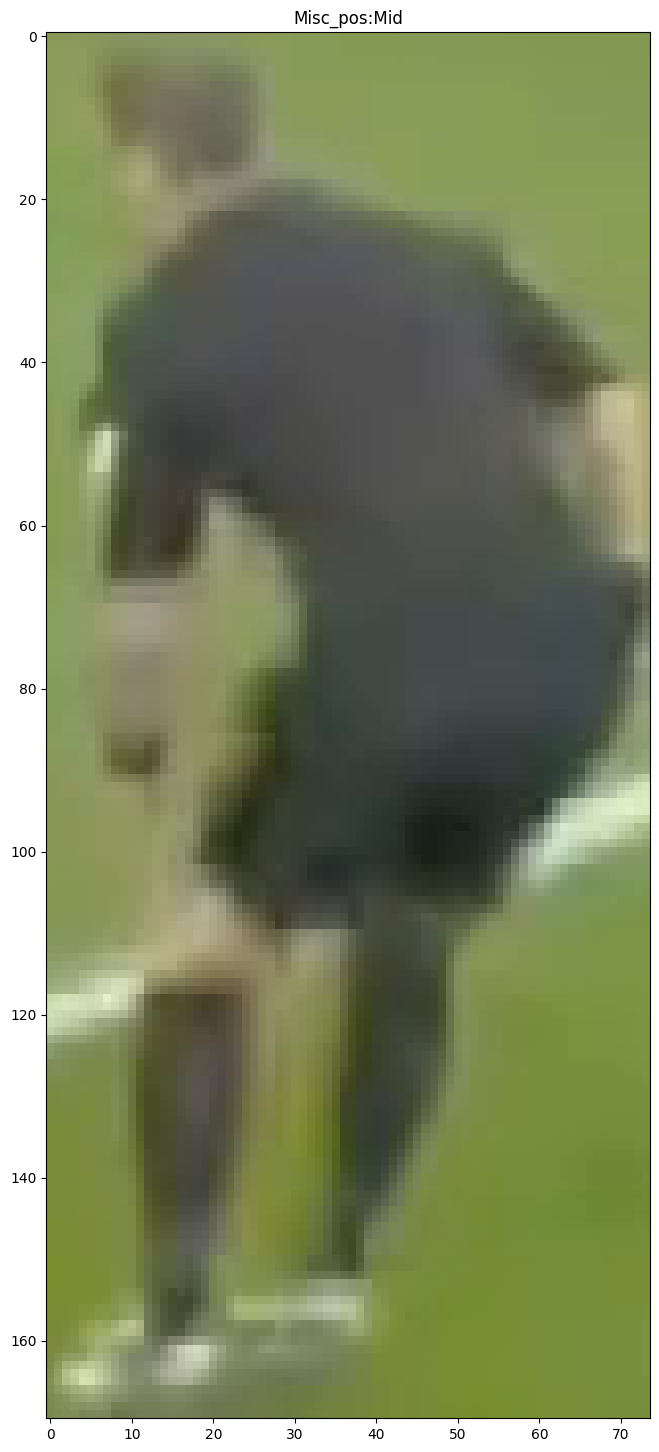

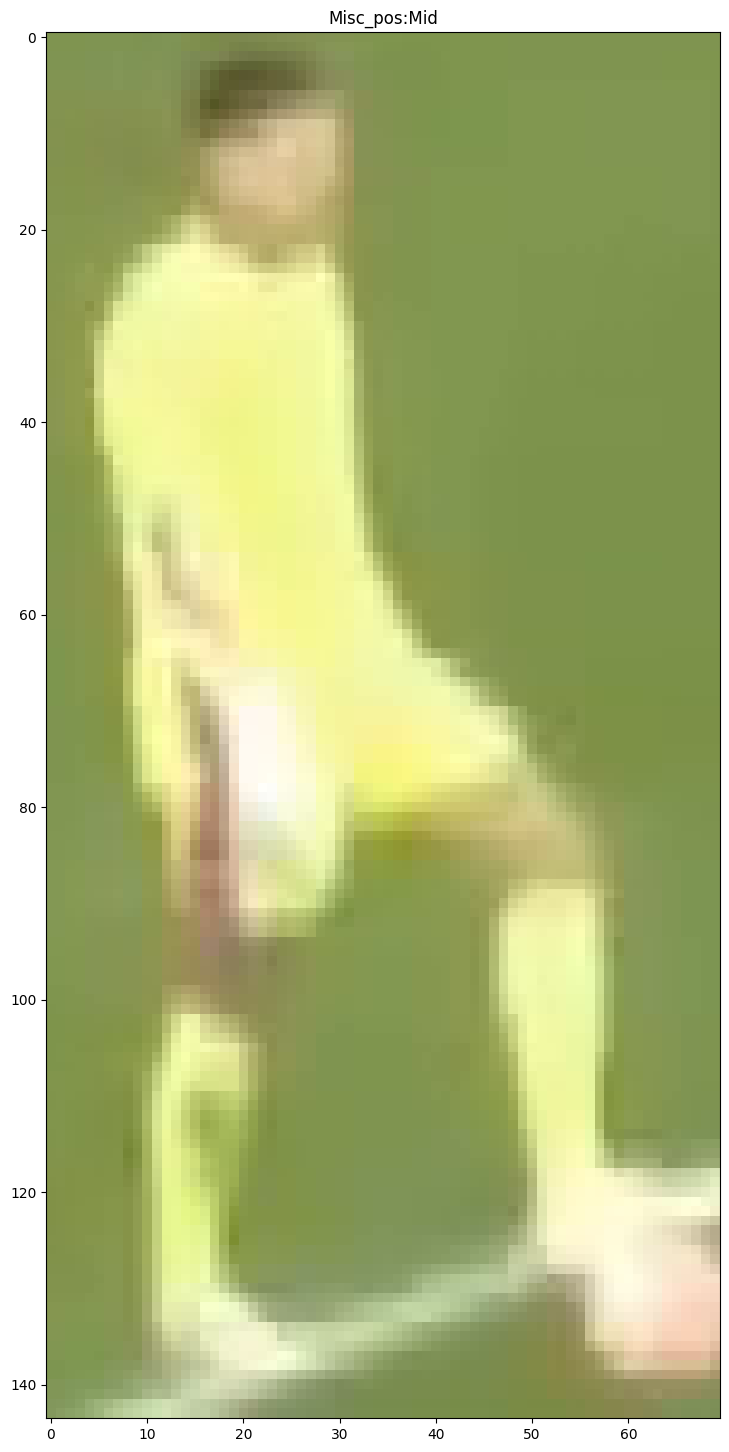

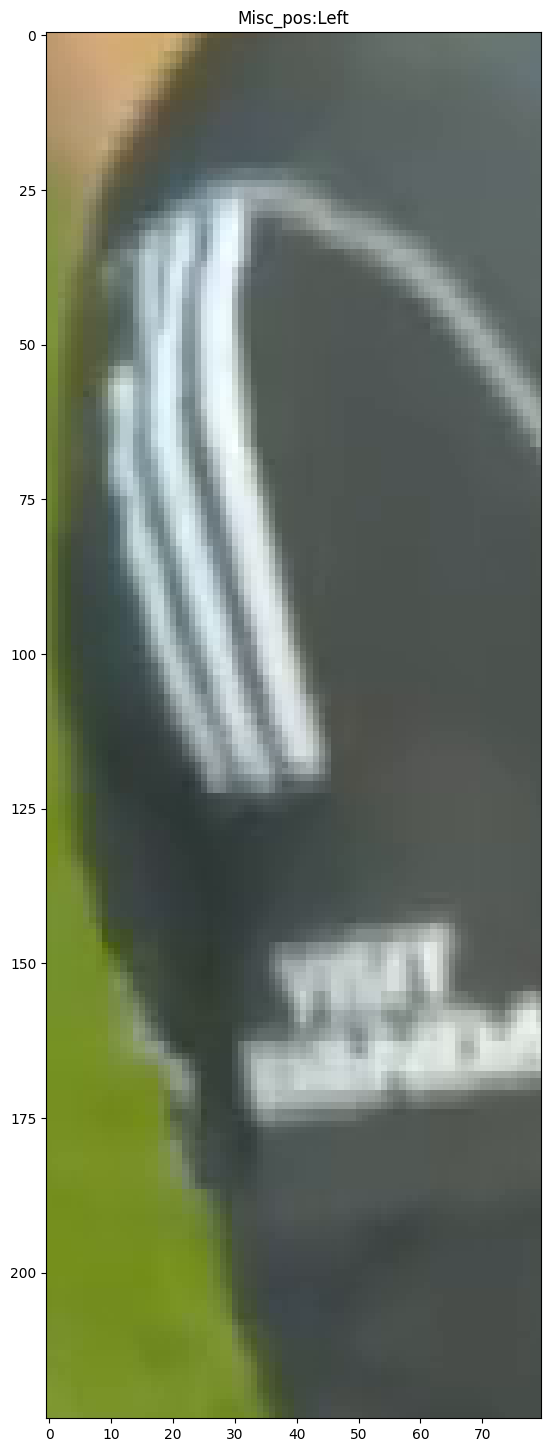

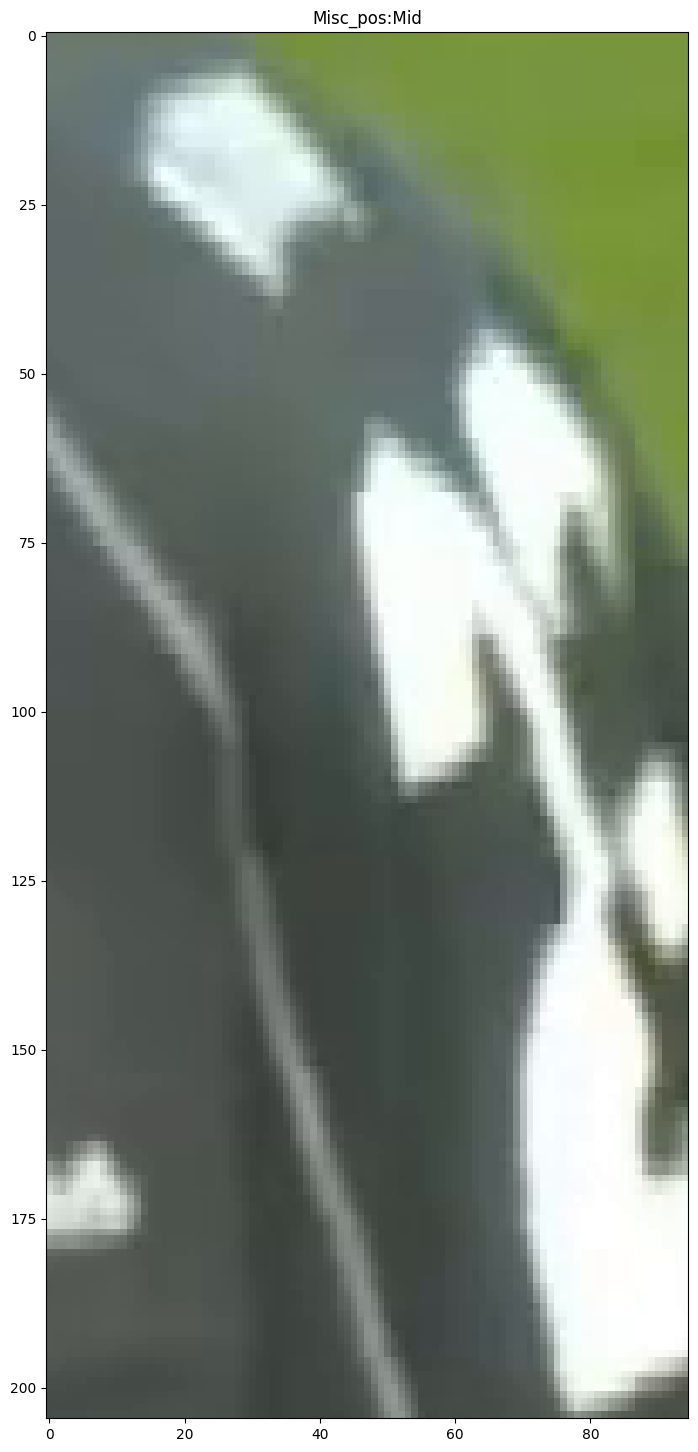

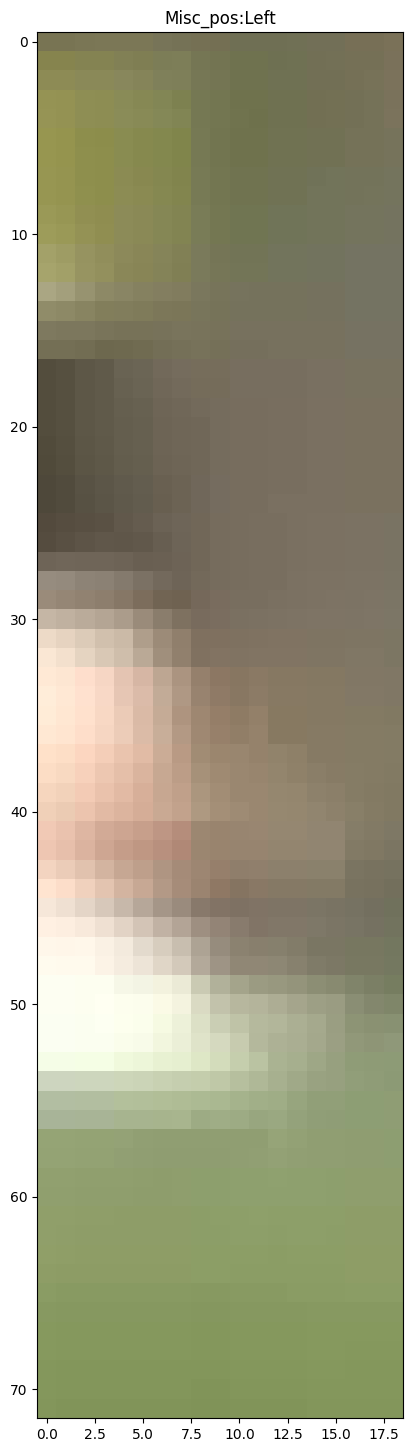

In [44]:
from sklearn.cluster import KMeans
from collections import Counter
from colormath.color_objects import sRGBColor, LabColor
from colormath.color_conversions import convert_color
from colormath.color_diff import delta_e_cie2000

# Get several images to test
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
#print(os.path.exists(images_path))
first_batch = os.listdir(images_path)[0:20]
image_batch = [os.path.join(images_path, x) for x in first_batch]

# Attributes to identify colors
team_1_color_global = []
team_2_color_global = []

misc_color_global   = []
misc_position_global = []
misc_frequency_global = []
misc_img_global = []


frame_num = 0


for image_ad in image_batch:
    
    # Crop out the audiences via pitch segmentation
    rgb_image = cv2.imread(image_ad, cv2.COLOR_BGR2RGB)
    rgb_image = pitch_segmentation(rgb_image)

    # Run yolov8n on the current image and extract features from resulting boxes
    results = model.predict(rgb_image)
    boxes = results[0].boxes
    assignment,player_x_coord,crop_img_list = box_to_features(rgb_image, boxes)

    # Applies KNN with 3 clusters to find the most prominent colors
    kmeans = KMeans(n_clusters=3)
    s=kmeans.fit(assignment)
    labels=kmeans.labels_
    # Extract the labels into 2 teams and misc color
    teams = Counter(labels).most_common(3)
    team_1 = np.where(labels == teams[0][0])[0]
    team_2 = np.where(labels == teams[1][0])[0]
    misc   = np.where(labels == teams[2][0])[0]

    team_1_color = np.mean([assignment[i] for i in team_1],axis =0)
    team_2_color = np.mean([assignment[i] for i in team_2],axis =0)
        
    # Convert to CLE metric
    lab_team_1_color = rgb_to_lab(team_1_color)
    lab_team_2_color = rgb_to_lab(team_2_color)
    lab_assignment = [rgb_to_lab(x) for x in assignment]
    #Correct labels of (numbers)
    labels = misc_in_teams(labels,lab_assignment,lab_team_1_color,lab_team_2_color,teams,team_1,team_2)

    # Labeling via strings and consistency checks so that team X is always color Y:
    if frame_num == 0:
        team_1_color_global = lab_team_1_color 
        team_2_color_global = lab_team_2_color

        labels = list(map(lambda x: x if x != teams[0][0] else 'Team 1', labels))
        labels = list(map(lambda x: x if x != teams[1][0] else 'Team 2', labels))
        labels = list(map(lambda x: x if x != teams[2][0] else 'Misc', labels))
        
    if frame_num > 0:
        global_1_vs_local_1 = delta_e_cie2000(team_1_color_global, lab_team_1_color)
        global_1_vs_local_2 = delta_e_cie2000(team_1_color_global, lab_team_2_color)
        if  global_1_vs_local_1 < global_1_vs_local_2:
            labels = list(map(lambda x: x if x != teams[0][0] else 'Team 1', labels))
            labels = list(map(lambda x: x if x != teams[1][0] else 'Team 2', labels))
        else: 
            labels = list(map(lambda x: x if x != teams[1][0] else 'Team 1', labels))
            labels = list(map(lambda x: x if x != teams[0][0] else 'Team 2', labels))
        labels = list(map(lambda x: x if x != teams[2][0] else 'Misc', labels)) 

    # Positional of the two teams
    new_team_1 = np.where(np.array(labels) == "Team 1")[0]
    new_team_2 = np.where(np.array(labels) == "Team 2")[0]
    new_misc   = np.where(np.array(labels) == "Misc")[0]    
    
    
    # Update the misc color: 
    current_misc_img   = [crop_img_list[i] for i in new_misc]
    current_misc_color = [assignment[i] for i in new_misc]
    current_misc_lab   = [rgb_to_lab(x) for x in current_misc_color]
    global_misc_lab    = [rgb_to_lab(x) for x in misc_color_global]
    team_1_diff = [delta_e_cie2000(team_1_color_global,x) for x in current_misc_lab]
    team_2_diff = [delta_e_cie2000(team_2_color_global,x) for x in current_misc_lab]
    current_misc_pos   = position_text(player_x_coord,new_team_1,new_team_2,new_misc)
    switch = [False]*len(current_misc_lab)


    # Check availability of the misc clr:
    if len(misc_color_global) == 0:
        for j in range(len(current_misc_color)):
            # If the same shade of color then update the param of existing global, but if it is not then addd into the list
            if (team_1_diff[j] < 30) or (team_2_diff[j] < 30):
                switch[j] = True
            if switch[j] == False:
                misc_img_global.append(current_misc_img[j])
                misc_color_global.append(current_misc_color[j])
                misc_position_global.append(current_misc_pos[j])
                misc_frequency_global.append(1)
    else:
        #global vs local:
        for j in range(len(current_misc_lab)):
            # If the same shade of color then update the param of existing global, but if it is not then add into the list
            if (team_1_diff[j] < 30) or (team_2_diff[j] < 30):
                switch[j] = True
            for i in range(len(global_misc_lab)):
                misc_diff = delta_e_cie2000(global_misc_lab[i], current_misc_lab[j])
                if misc_diff < 40:
                    if current_misc_pos[j] == misc_position_global[i]:
                        misc_frequency_global[i] += 1
                    else:
                        misc_frequency_global[i] += 1
                        misc_position_global[i] = "Mid"
                    switch[j] = True

        for j in range(len(current_misc_lab)):
            if switch[j] == False:
                if len(misc_color_global) <= 4:
                    misc_img_global.append(current_misc_img[j])
                    misc_color_global.append(current_misc_color[j])
                    misc_position_global.append(current_misc_pos[j])
                    misc_frequency_global.append(1)
                else:
                    if min(misc_frequency_global) == 1:
                        k = misc_frequency_global.index(min(misc_frequency_global))
                        misc_img_global[k] = current_misc_img[j]
                        misc_color_global[k] = current_misc_color[j]
                        misc_position_global[k] = current_misc_pos[j]
                        misc_frequency_global[k] = 1
    
    frame_num +=1

#for r in range(len(misc_img_global)):
#    plt.figure()
#    plt.title("Misc_pos:" + misc_position_global[r])
#    plt.imshow(misc_img_global[r])
#print(misc_frequency_global)

In [ ]:
def patch_asscalar(a):
    return a.item()

setattr(np, "asscalar", patch_asscalar)